# CNN Model

Trains a CNN on freeze-frame heatmaps (3 x 68 x 52) and compares against LR and XGBoost baselines.

Architecture: 2x Conv+ReLU+MaxPool → Flatten → Linear(7072, 64) → Dropout → Linear(64, 1) → Sigmoid

## 1. Load Data

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import roc_auc_score, brier_score_loss

from data import load_features, split_data
from models import train_baseline, train_xgboost, train_cnn, make_X_tabular, XGNet
from evaluate import evaluate

features_df = load_features()
train, val, test = split_data(features_df)

print(f"Train: {len(train)} shots | {train['is_goal'].mean():.1%} goals")
print(f"Val:   {len(val)} shots | {val['is_goal'].mean():.1%} goals")
print(f"Test:  {len(test)} shots | {test['is_goal'].mean():.1%} goals")
print(f"\nDevice: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Loading existing features from cache...
Train: 5090 | Val: 1150 | Test: 1182
Train: 5090 shots | 10.1% goals
Val:   1150 shots | 8.3% goals
Test:  1182 shots | 9.3% goals

Device: cuda


## 2. Verify Heatmap Input Shape

In [2]:
# Confirm input shape matches CNN architecture (3, 68, 52)
sample = np.stack(train['heatmap'].values)
print(f"Heatmap batch shape: {sample.shape}")
print(f"Expected:            (n, 3, 68, 52)")
assert sample.shape[1:] == (3, 68, 52), "❌ Unexpected heatmap shape!"
print("✅ Shape confirmed")

Heatmap batch shape: (5090, 3, 68, 52)
Expected:            (n, 3, 68, 52)
✅ Shape confirmed


## 3. Train CNN

In [3]:
# Train CNN — pass val for loss tracking per epoch
# Expects train_cnn to return (model, train_losses, val_losses)
model_cnn, train_losses, val_losses = train_cnn(train, val, epochs=50, batch_size=64, lr=0.001)

Epoch   5 | Train Loss: 1.0577 | Val Loss: 0.9668
--> Early stopping at epoch 9. Best Val Loss: 0.9557


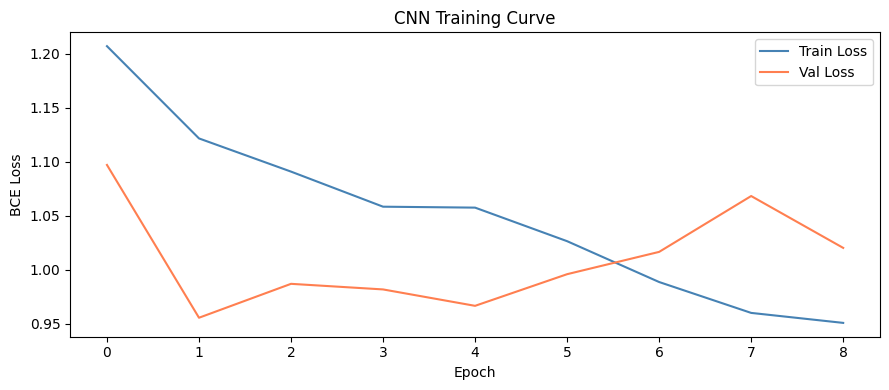

In [4]:
# Plot training curve — check for overfitting
# Ideal: both curves decrease and stay close together
# Red flag: val loss increases while train loss keeps dropping → overfitting
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train Loss', color='steelblue')
ax.plot(val_losses,   label='Val Loss',   color='coral')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('CNN Training Curve')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Evaluate CNN

In [5]:
# Get CNN predictions on val set
model_cnn.eval()
X_val_heatmap = torch.tensor(
    np.stack(val['heatmap'].values), dtype=torch.float32
)
y_val = val['is_goal'].values

with torch.no_grad():
    y_proba_cnn = torch.sigmoid(model_cnn(X_val_heatmap)).numpy()

auc_cnn   = roc_auc_score(y_val, y_proba_cnn)
brier_cnn = brier_score_loss(y_val, y_proba_cnn)
print(f"CNN   →  AUC: {auc_cnn:.3f}  |  Brier: {brier_cnn:.4f}")

CNN   →  AUC: 0.769  |  Brier: 0.1453


## 5. Full Model Comparison

In [6]:
# Train all models for comparison
model_lr  = train_baseline(train)
model_xgb = train_xgboost(train)

# LR
X_val_lr  = val[['distance', 'angle']].values
auc_lr    = roc_auc_score(y_val, model_lr.predict_proba(X_val_lr)[:, 1])
brier_lr  = brier_score_loss(y_val, model_lr.predict_proba(X_val_lr)[:, 1])

# XGBoost
X_val_xgb = make_X_tabular(val)
auc_xgb   = roc_auc_score(y_val, model_xgb.predict_proba(X_val_xgb)[:, 1])
brier_xgb = brier_score_loss(y_val, model_xgb.predict_proba(X_val_xgb)[:, 1])

# StatsBomb reference
sb_xg     = val['statsbomb_xg'].values
mask      = ~np.isnan(sb_xg)
auc_sb    = roc_auc_score(y_val[mask], sb_xg[mask])
brier_sb  = brier_score_loss(y_val[mask], sb_xg[mask])

# Print comparison table
print(f"{'Model':<28} {'AUC':>6}  {'Brier':>7}")
print("-" * 45)
print(f"{'Logistic Regression':<28} {auc_lr:>6.3f}  {brier_lr:>7.4f}")
print(f"{'XGBoost':<28} {auc_xgb:>6.3f}  {brier_xgb:>7.4f}")
print(f"{'CNN (heatmap only)':<28} {auc_cnn:>6.3f}  {brier_cnn:>7.4f}")
print("-" * 45)
print(f"{'StatsBomb xG (reference)':<28} {auc_sb:>6.3f}  {brier_sb:>7.4f}")

Model                           AUC    Brier
---------------------------------------------
Logistic Regression           0.758   0.0705
XGBoost                       0.796   0.0690
CNN (heatmap only)            0.769   0.1453
---------------------------------------------
StatsBomb xG (reference)      0.820   0.0650


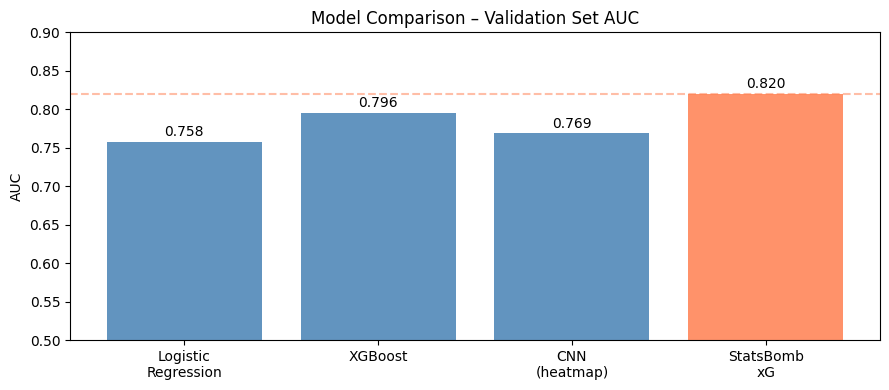

In [7]:
# Visual comparison of AUC scores
models  = ['Logistic\nRegression', 'XGBoost', 'CNN\n(heatmap)', 'StatsBomb\nxG']
aucs    = [auc_lr, auc_xgb, auc_cnn, auc_sb]
colors  = ['steelblue', 'steelblue', 'steelblue', 'coral']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(models, aucs, color=colors, alpha=0.85)
ax.set_ylim(0.5, 0.9)
ax.set_ylabel('AUC')
ax.set_title('Model Comparison – Validation Set AUC')
ax.axhline(auc_sb, color='coral', linestyle='--', alpha=0.5, label='StatsBomb reference')

# Value labels on bars
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{auc:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 6. xG Distribution – CNN vs. Ground Truth

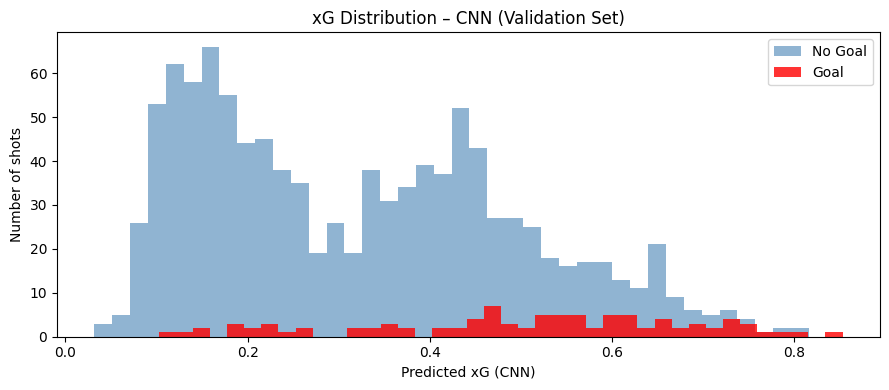

In [8]:
# Does the CNN assign higher xG to actual goals?
# Goals should cluster toward the right (higher xG)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y_proba_cnn[y_val == 0], bins=40, alpha=0.6, label='No Goal', color='steelblue')
ax.hist(y_proba_cnn[y_val == 1], bins=40, alpha=0.8, label='Goal',    color='red')
ax.set_xlabel('Predicted xG (CNN)')
ax.set_ylabel('Number of shots')
ax.set_title('xG Distribution – CNN (Validation Set)')
ax.legend()
plt.tight_layout()
plt.show()